# Create table and txs

In [ ]:
import os
import subprocess
import glob

# ------------------------------------------------------------------------------
# Configuration: Paths to the Python scripts (relative to the notebook)
# ------------------------------------------------------------------------------
gen_tables_path = os.path.join("gen_py", "gen_tables.py")           # Path to gen_tables.py
gen_inc_update_path = os.path.join("gen_py", "gen_inc_update.py")     # Path to gen_inc_update.py
gen_res_path = os.path.join("gen_py", "gen_res.py")                 # Path to gen_rec.py

# CSV folder is assumed to be at ../csv relative to the scripts
csv_dir = os.path.join(os.path.dirname(os.path.abspath(gen_tables_path)), "..", "csv")

# ------------------------------------------------------------------------------
# 1) Delete existing CSV files in CSV folder
# ------------------------------------------------------------------------------
print(f"Deleting existing CSV files in: {csv_dir}")
if os.path.exists(csv_dir):
    for f in glob.glob(os.path.join(csv_dir, "*.csv")):
        os.remove(f)
    print("Old CSV files deleted.\n")
else:
    print("CSV folder does not exist. It will be created by the scripts.\n")

# ------------------------------------------------------------------------------
# 2) Run gen_tables.py to generate tables
# ------------------------------------------------------------------------------
cmd_tables = [
    "python3", gen_tables_path,   # Run gen_tables.py using python3
    "-T", "2",                    # Number of tables to generate (table_0.csv, table_1.csv)
    "-r", "100_000", "1_000",                # Number of rows per table (applies to all tables)
    "-jks", "1_000",                # Join key pool size
    "-jk", "100",                 # Join key size
    "-pk", "100",                 # Primary key size
    "-minv", "800",               # Minimum value length
    "-maxv", "800"                # Maximum value length
]

print("Running gen_tables.py with command:")
print(" ".join(cmd_tables), "\n")
result_tables = subprocess.run(cmd_tables, capture_output=True, text=True)
print("gen_tables.py STDOUT:")
print(result_tables.stdout)
print("gen_tables.py STDERR:")
print(result_tables.stderr)

# ------------------------------------------------------------------------------
# 3) Run gen_inc_update.py to generate incremental update logs and join logs
# ------------------------------------------------------------------------------
# Here we pass:
# - Base table file name for table_0 ("table_0.csv")
# - Number of transactions per coverage file (-ntx)
# - Minimum, maximum, and step coverage fractions (as configurable parameters)
# - Operation ratios (we assume only updates, so update_ratio=1, others=0)
# - Join TX configuration (-tjt)
# - And the new ts-values list for join logs (--ts-values)
cmd_inc_update = [
    "python3", gen_inc_update_path,
    "-t0", "table_0.csv",         # Base table_0 CSV filename
    "-ntx", "100",                  # Number of transactions for each coverage log
    "-mintx", "0.1",              # Minimum coverage fraction (e.g., 0.1 for 10%)
    "-maxtx", "1.0",              # Maximum coverage fraction (e.g., 1.0 for 100%)
    "-steptx", "0.1",             # Step size (e.g., 0.1 => 10% increments)
    "-ir", "0",                   # Insert ratio (0 if only updates)
    "-gr", "0",                   # Get ratio
    "-ur", "1",                   # Update ratio
    "-dr", "0",                   # Delete ratio
    "-tjt", "1",                 # Number of transactions for each discovered join table
    "--ts-values", "1", "50", "100"  # TS values list for join logs
]

print("\nRunning gen_inc_update.py with command:")
print(" ".join(cmd_inc_update), "\n")
result_inc_update = subprocess.run(cmd_inc_update, capture_output=True, text=True)
print("gen_inc_update.py STDOUT:")
print(result_inc_update.stdout)
print("gen_inc_update.py STDERR:")
print(result_inc_update.stderr)

# ------------------------------------------------------------------------------
# 4) Run gen_rec.py to generate recovery logs
# ------------------------------------------------------------------------------
# No need to pass any parameters to gen_rec.py
# cmd_res = ["python3", gen_res_path]

# print("\nRunning gen_rec.py with command:")
# print(" ".join(cmd_res), "\n")
# result_res = subprocess.run(cmd_res, capture_output=True, text=True)
# print("gen_rec.py STDOUT:")
# print(result_res.stdout)
# print("gen_rec.py STDERR:")
# print(result_res.stderr)

# ------------------------------------------------------------------------------
# 5) Print the configuration used for the generation
# ------------------------------------------------------------------------------
def get_cmd_option_value(cmd_list, option):
    """Return the value following an option in the list, or None if not found."""
    try:
        idx = cmd_list.index(option)
        return cmd_list[idx + 1]
    except (ValueError, IndexError):
        return None
    
# Extract values from the cmd_tables list
rows     = get_cmd_option_value(cmd_tables, "-r")
jks      = get_cmd_option_value(cmd_tables, "-jks")
jk       = get_cmd_option_value(cmd_tables, "-jk")
pk       = get_cmd_option_value(cmd_tables, "-pk")
minv     = get_cmd_option_value(cmd_tables, "-minv")
maxv     = get_cmd_option_value(cmd_tables, "-maxv")

# Extract the number of transactions from the cmd_inc_update list
tx_num   = get_cmd_option_value(cmd_inc_update, "-ntx")

# Compute the average value size
if minv is not None and maxv is not None:
    val_size = (int(minv) + int(maxv)) // 2
else:
    val_size = "N/A"

# Build the configuration string
config_str = (f"row: {rows}, key_pool: {jks}, key_size: {jk}, "
              f"pkey_size: {pk}, val_size: {val_size}, tx_num: {tx_num}")

print("Configuration:", config_str)

Deleting existing CSV files in: /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/hash_join/join_simulation/gen_py/../csv
Old CSV files deleted.

Running gen_tables.py with command:
python3 gen_py/gen_tables.py -T 2 -r 100_000 1_000 -jks 1_000 -jk 100 -pk 100 -minv 800 -maxv 800 

gen_tables.py STDOUT:
Generating a join key pool of size 1000 (each key length = 100) ...
  -> /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/hash_join/join_simulation/gen_py/../csv/key_pool.csv (contains 1000 keys).
Generating /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/hash_join/join_simulation/gen_py/../csv/table_0.csv with 100000 rows...
  -> /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/hash_join/join_simulation/gen_py/../csv/table_0.csv generated.
Generating /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/hash_join/join_simulation/gen_py/../csv/table_1.csv with 1000 rows...
  -> /Users/jun/Desktop/dev/mbp16/crustydb/riki/Fos

# Run join_simulation.rs

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Discovered coverage logs:
  coverage label='u0.1' => file=txs_u0.1_t0.csv
  coverage label='u0.2' => file=txs_u0.2_t0.csv
  coverage label='u0.3' => file=txs_u0.3_t0.csv
  coverage label='u0.4' => file=txs_u0.4_t0.csv
  coverage label='u0.5' => file=txs_u0.5_t0.csv
  coverage label='u0.6' => file=txs_u0.6_t0.csv
  coverage label='u0.7' => file=txs_u0.7_t0.csv
  coverage label='u0.8' => file=txs_u0.8_t0.csv
  coverage label='u0.9' => file=txs_u0.9_t0.csv
  coverage label='u1.0' => file=txs_u1.0_t0.csv

=== coverage='u0.1', file=txs_u0.1_t0.csv, hash_type=chain ===
   iteration 1/10
   iteration 2/10
   iteration 3/10
   iteration 4/10
   iteration 5/10
   iteration 6/10
   iteration 7/10
   iteration 8/10
   iteration 9/10
   iteration 10/10

=== coverage='u0.1', file=txs_u0.1_t0.csv, hash_type=heap ===
   iteration 1/10
   iteration 2/10
   iteration 3/10
   iteration 4/10
   iteration 5/10
   iteration 6

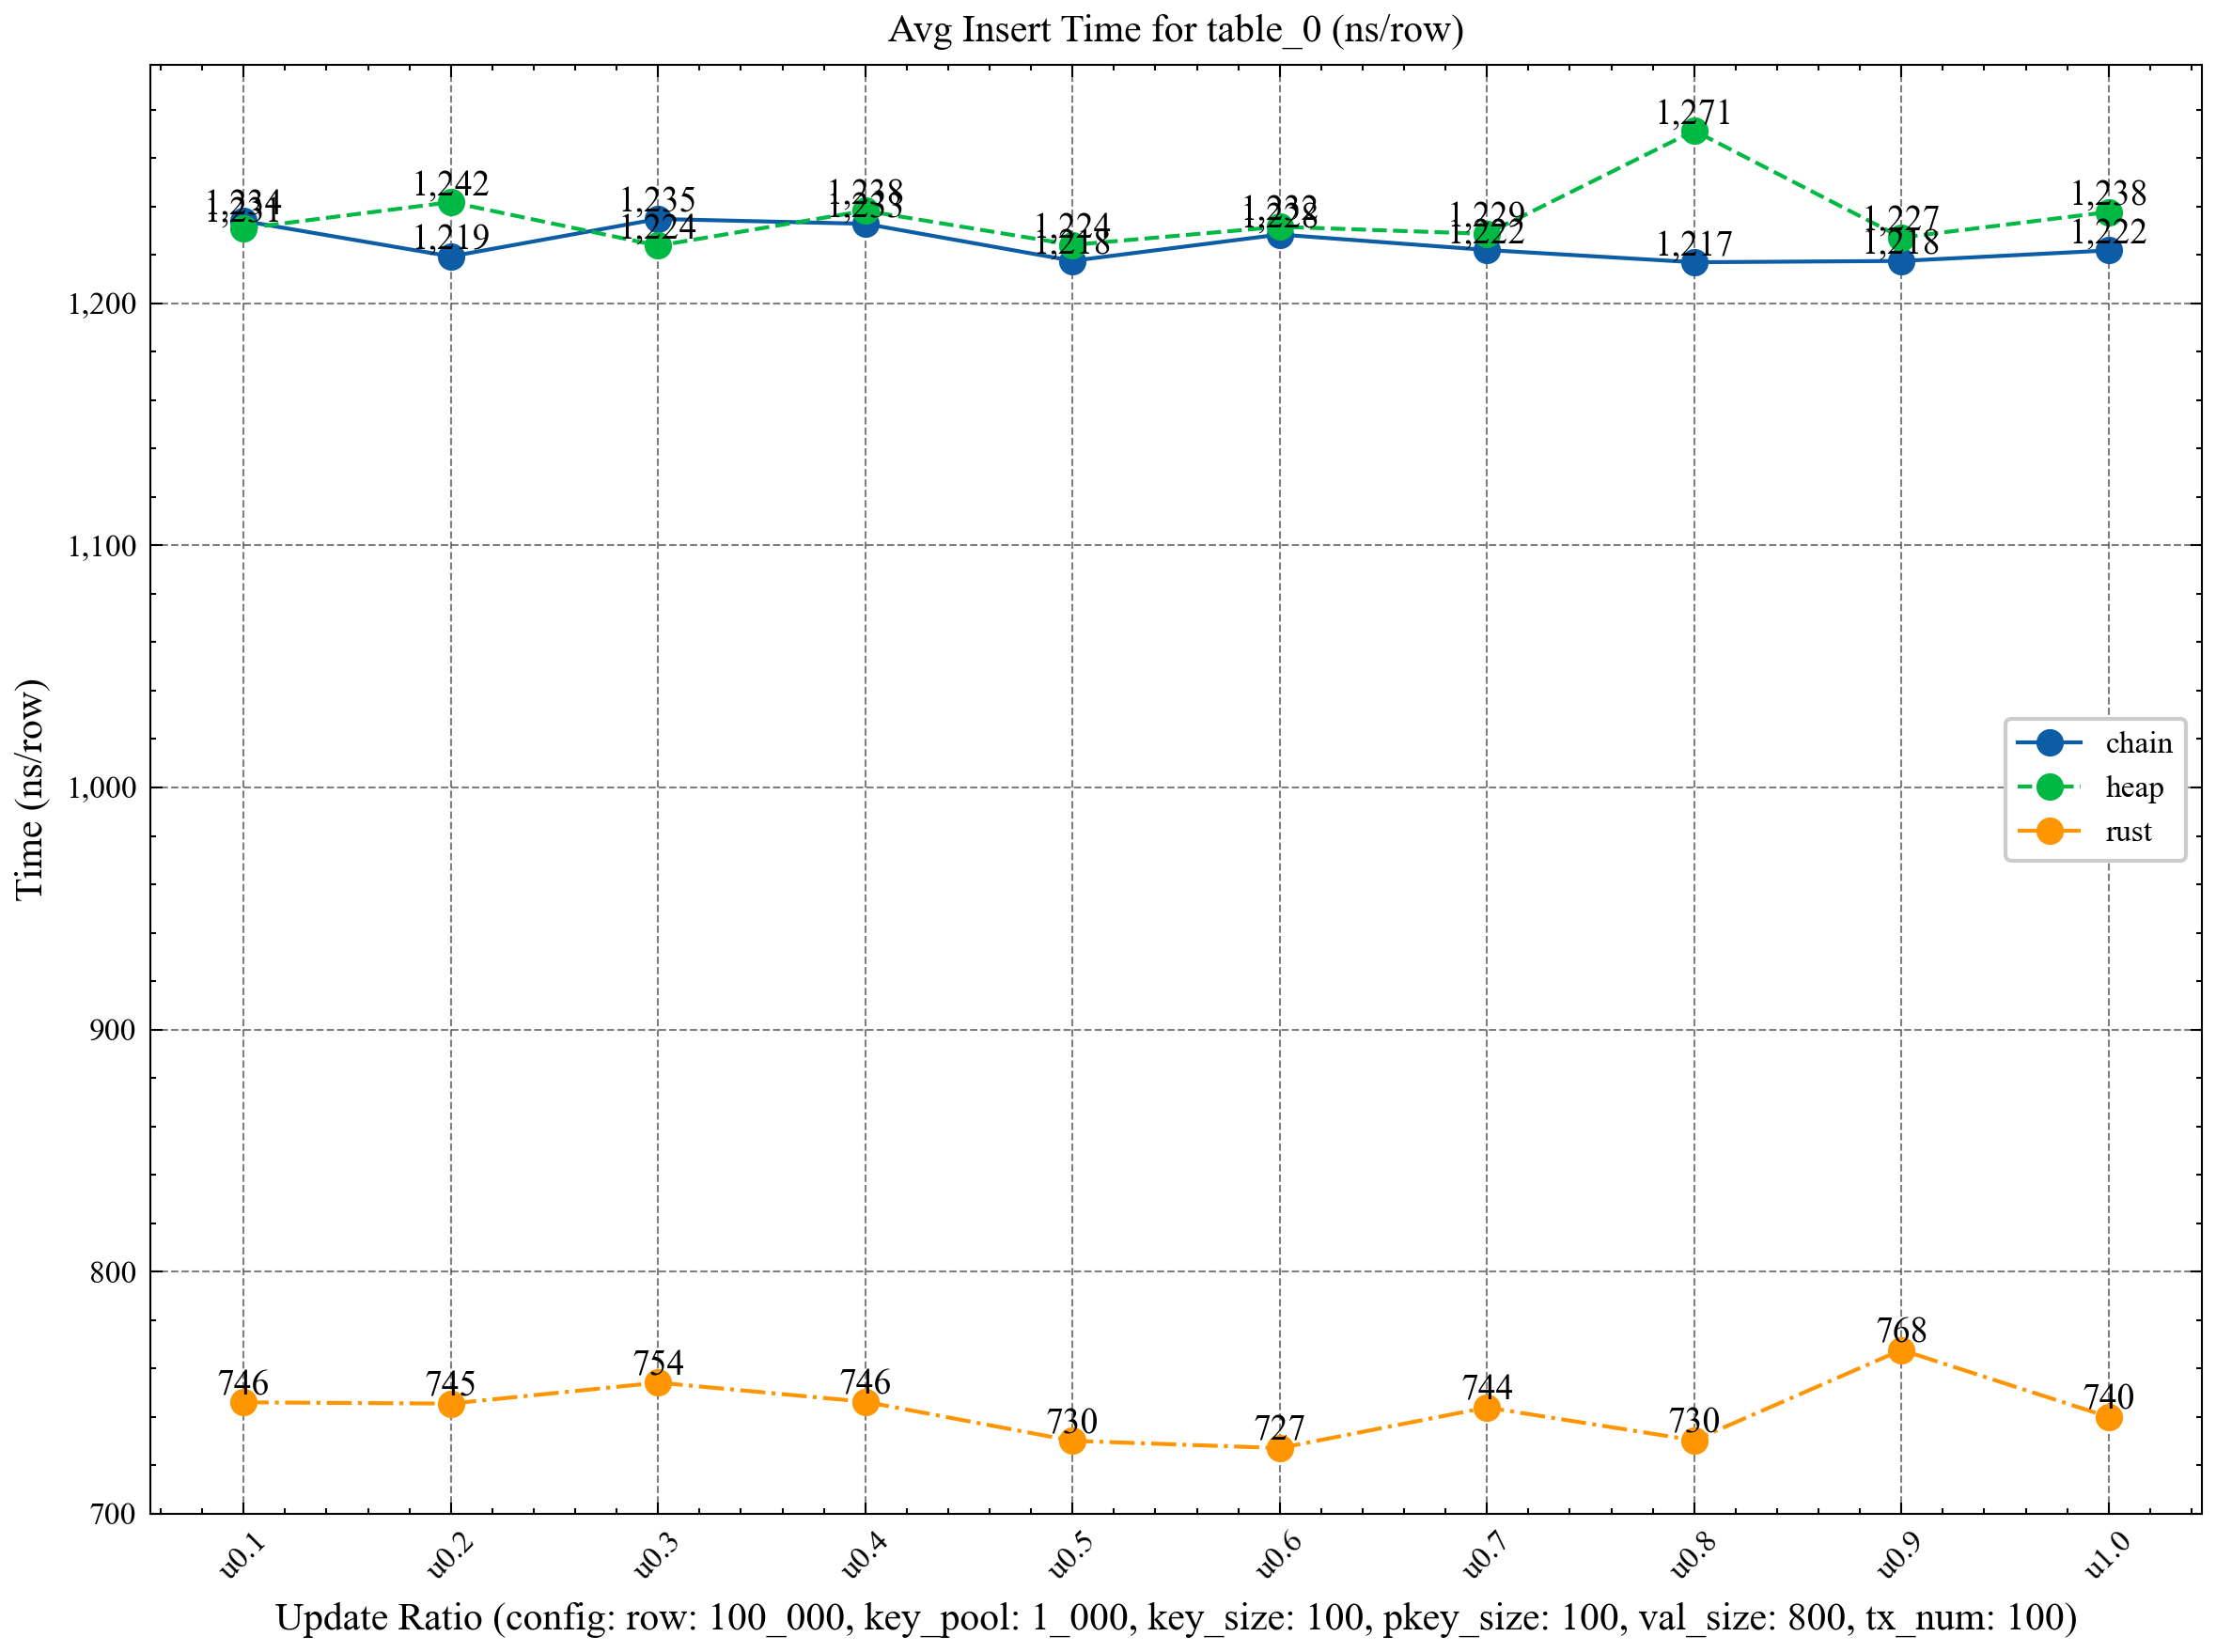

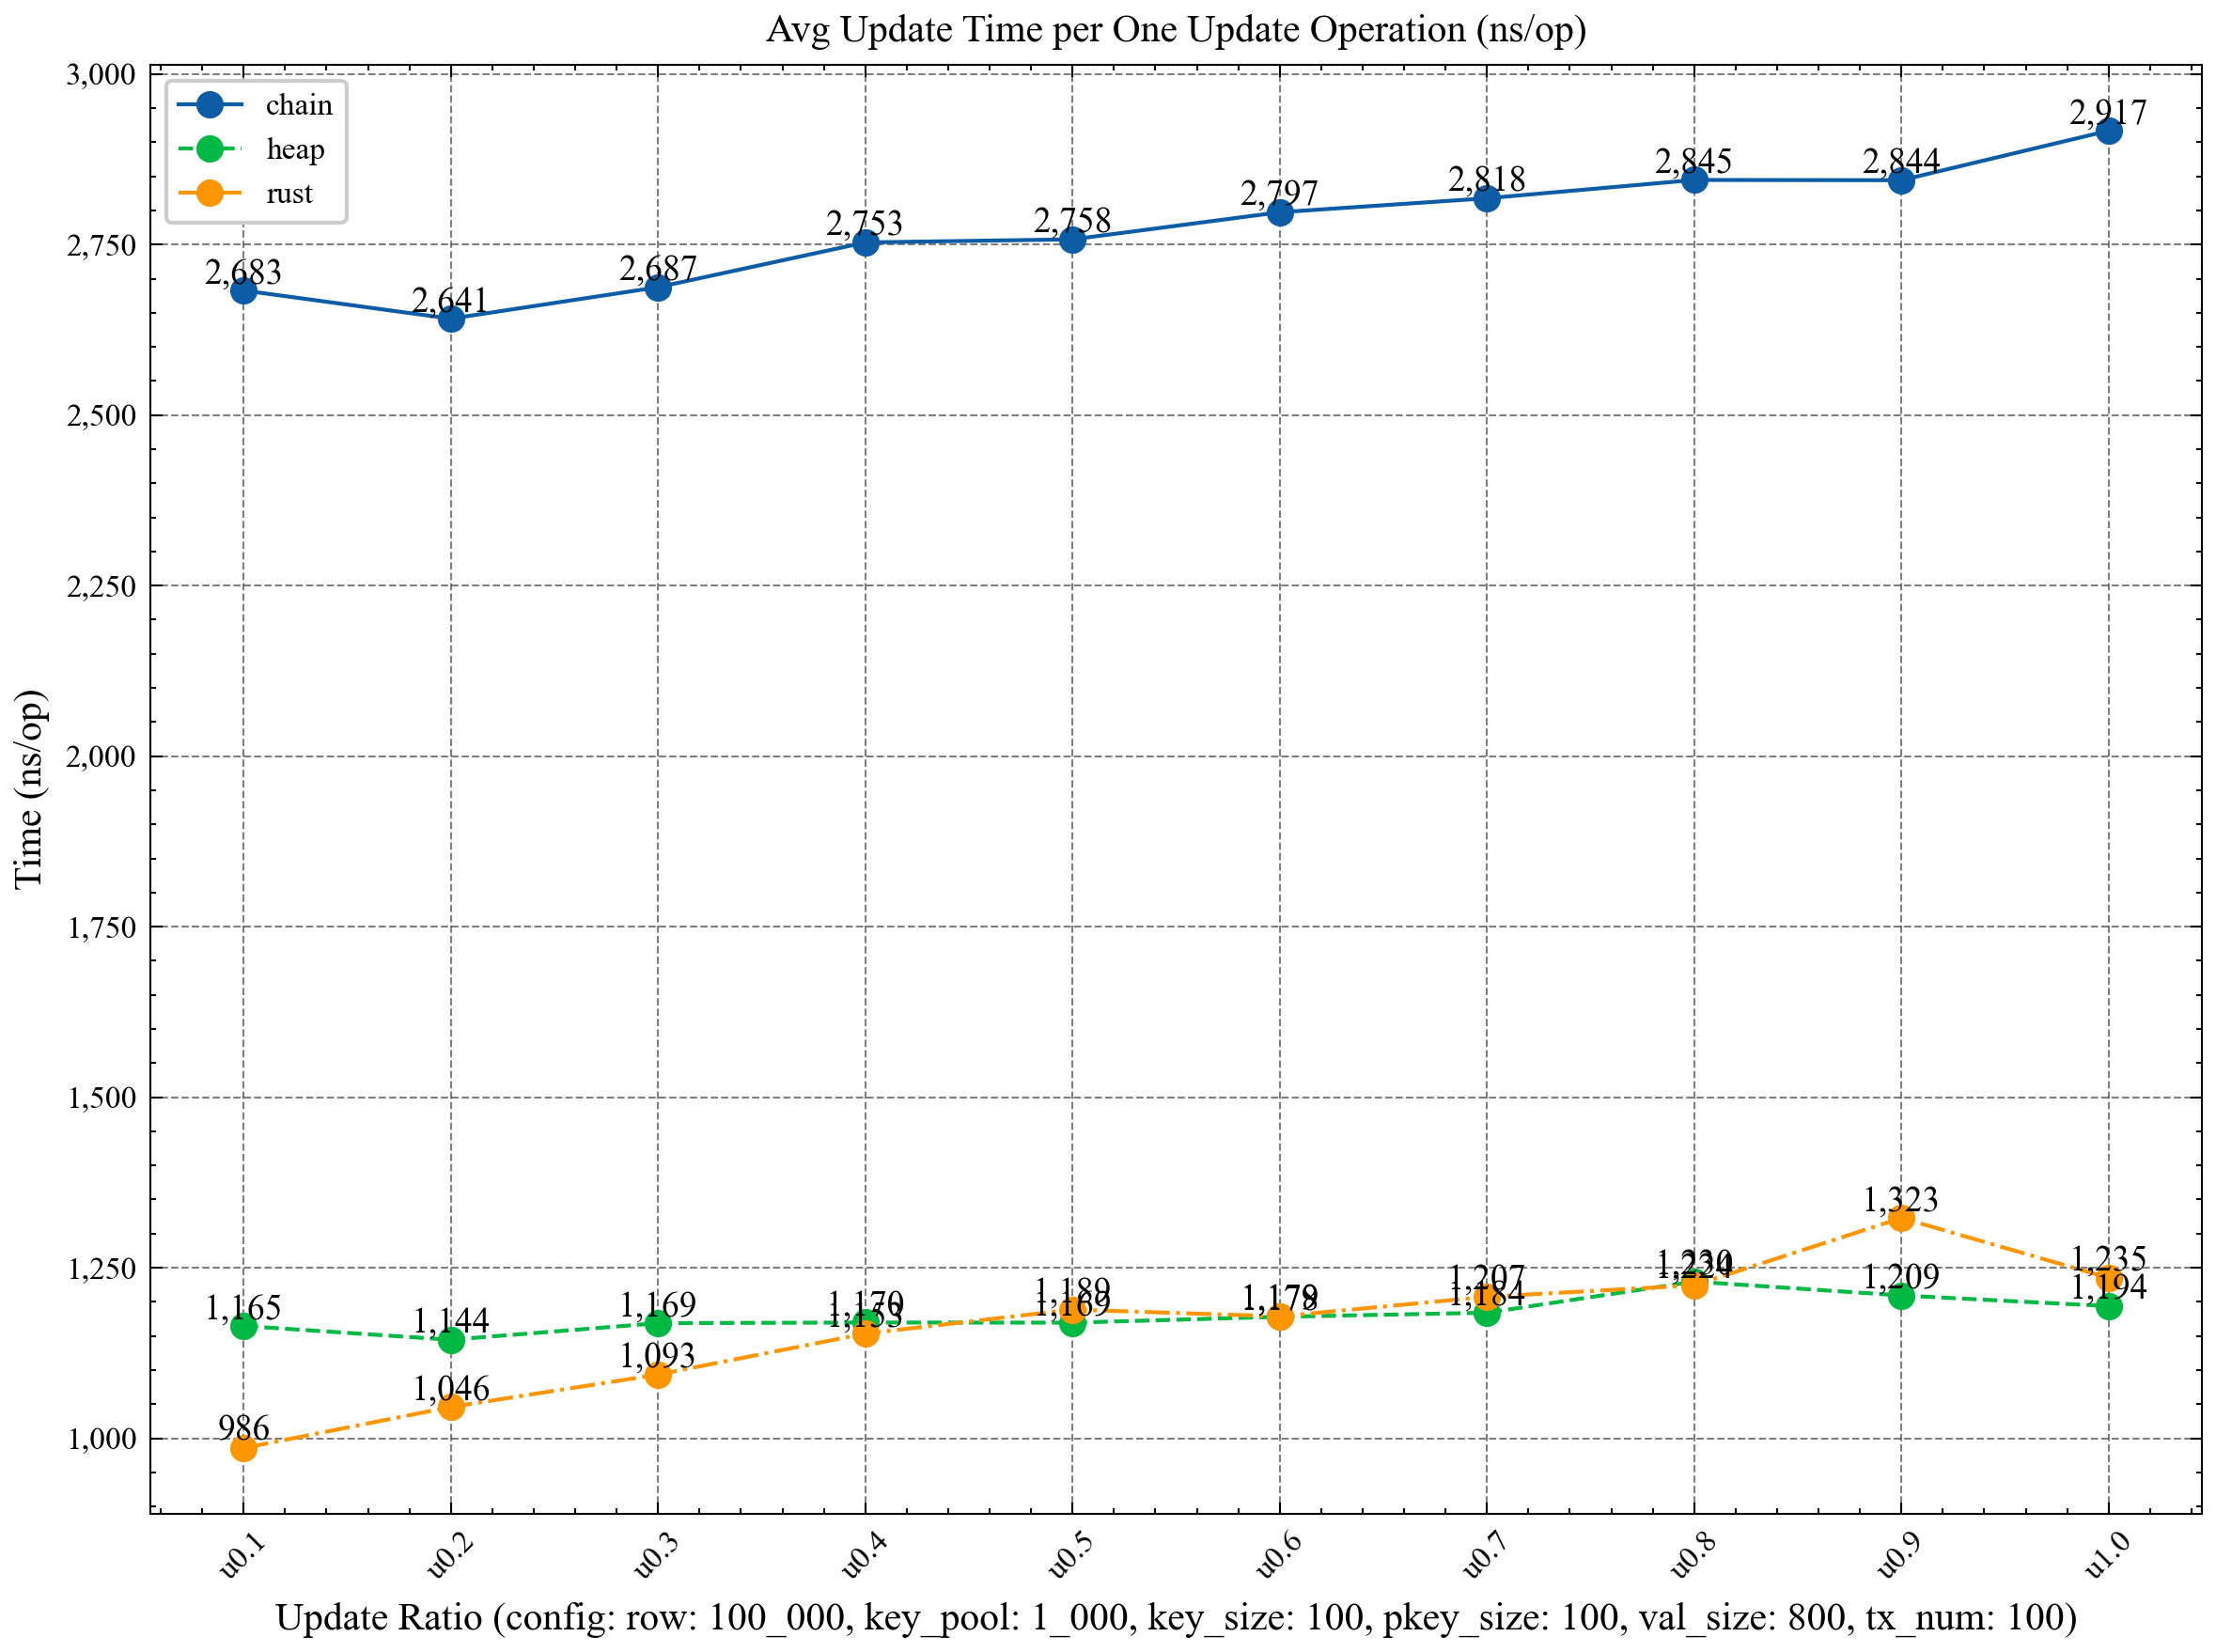

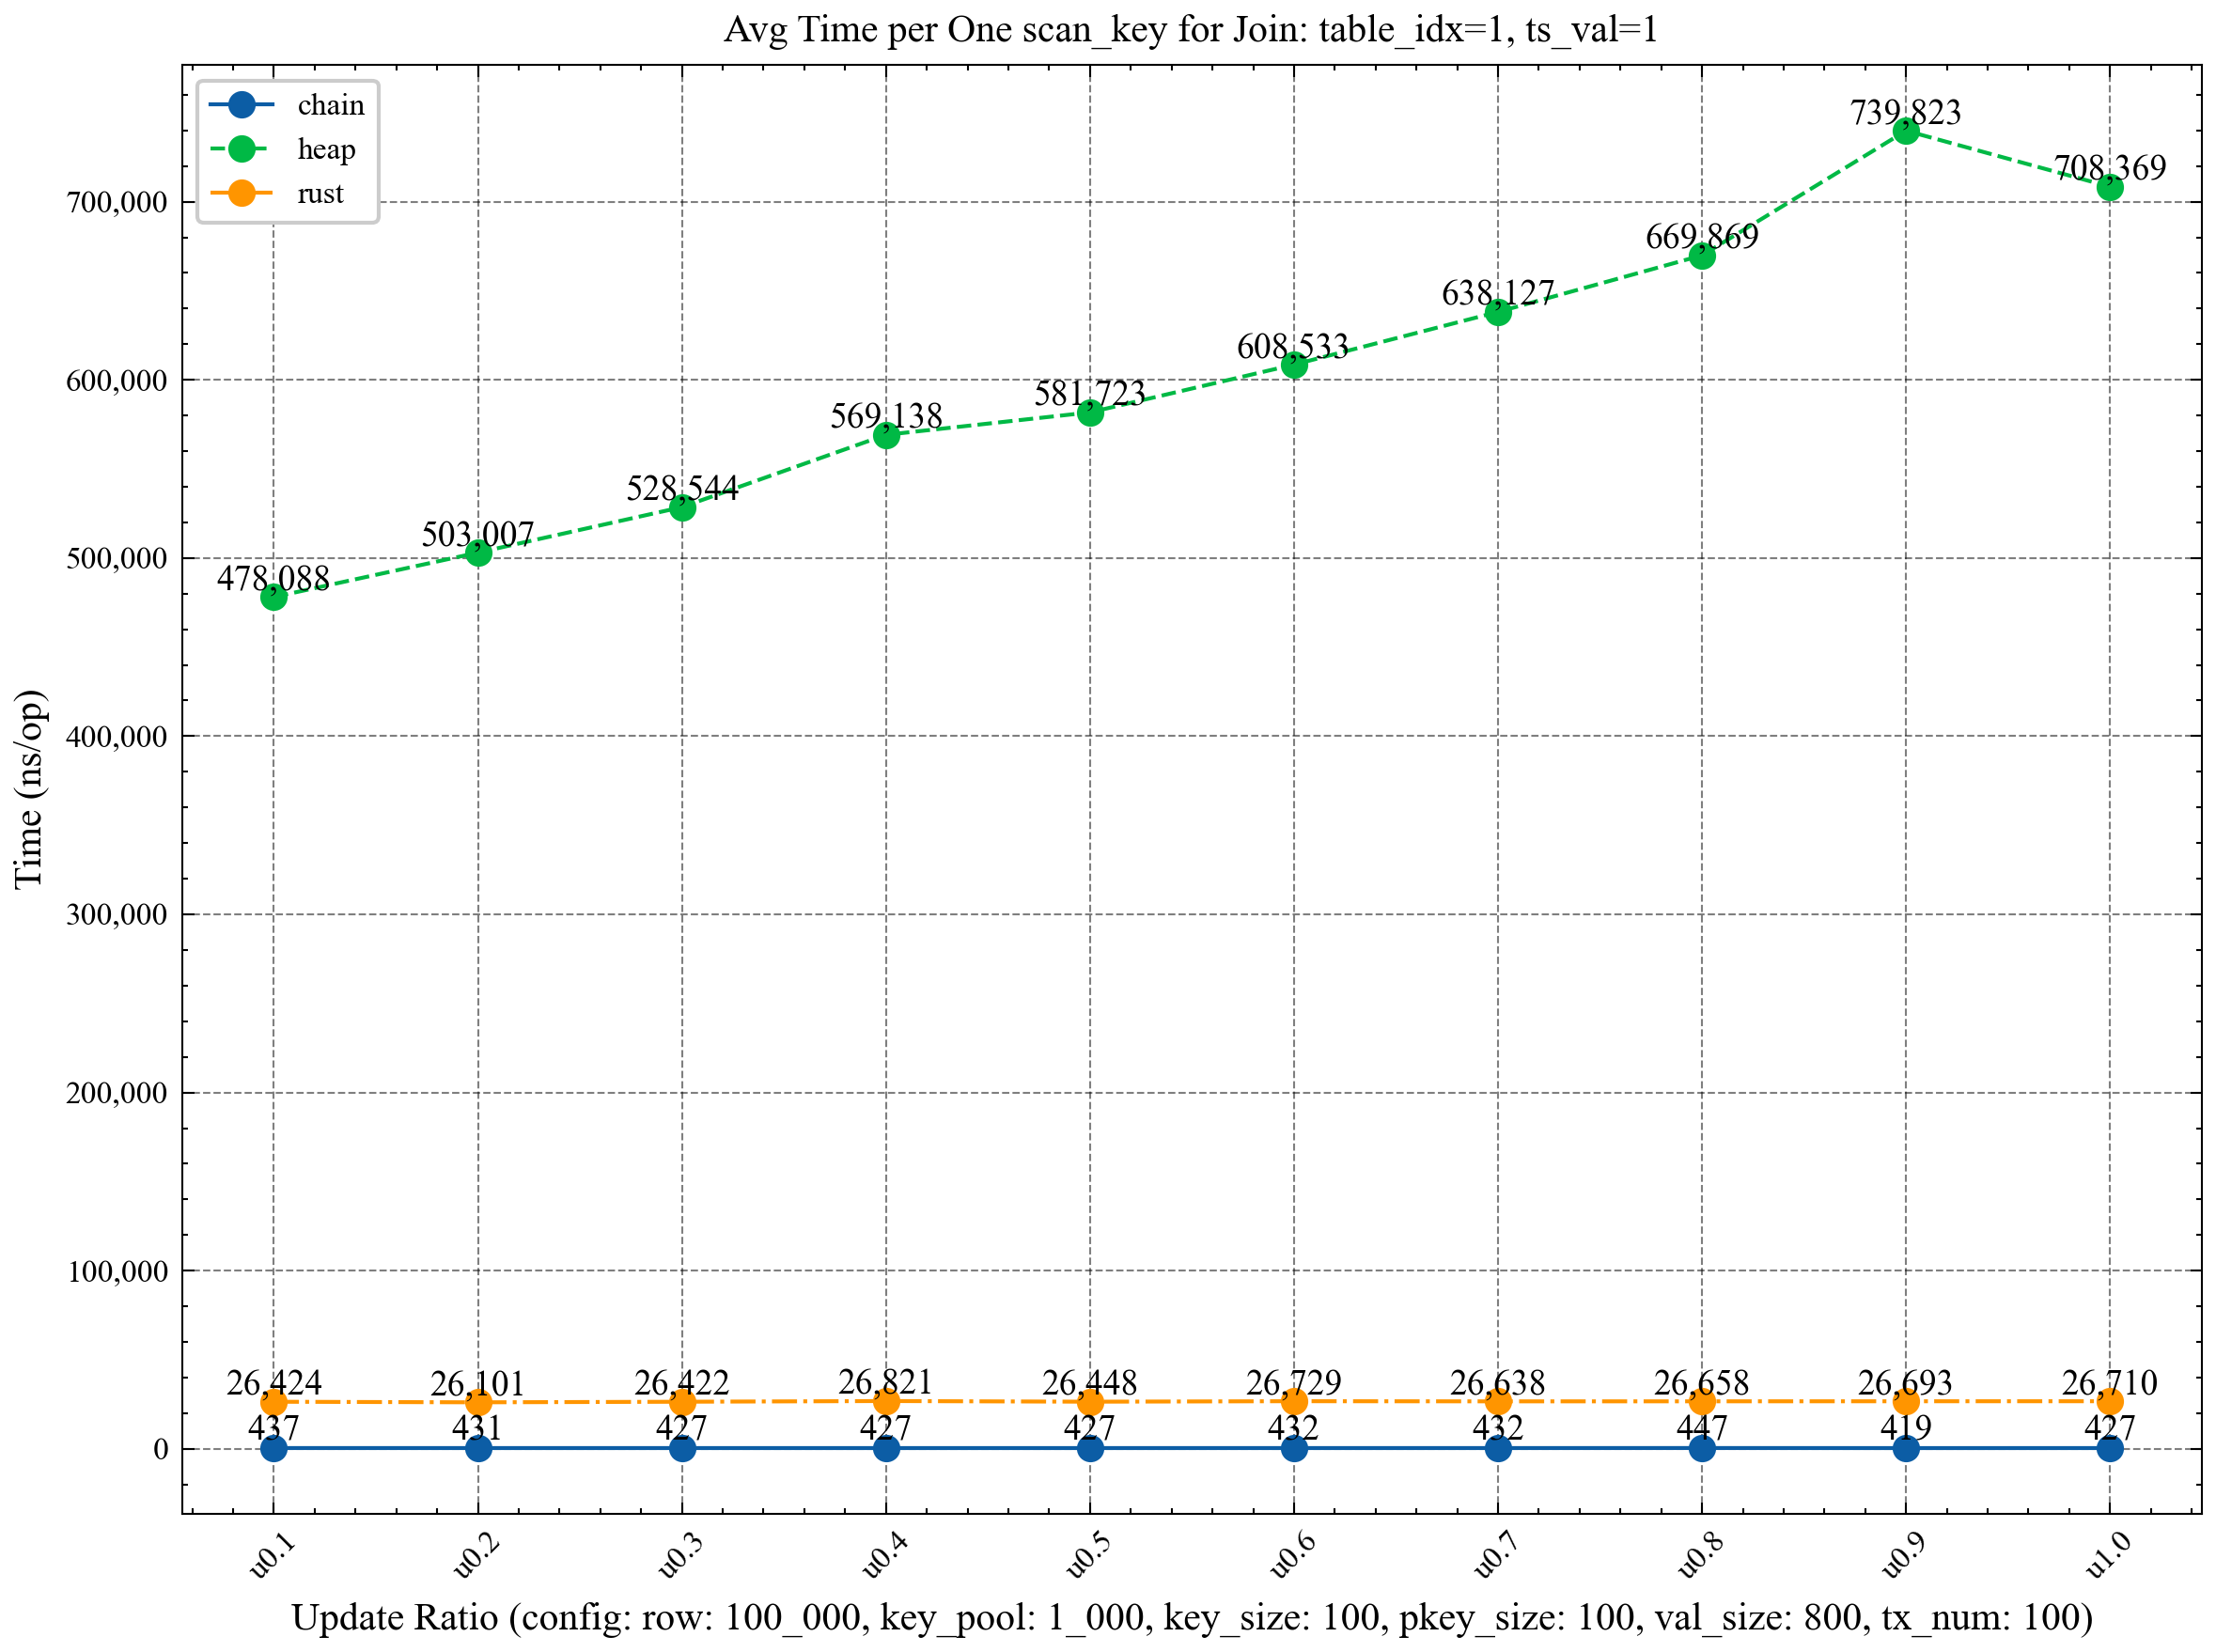

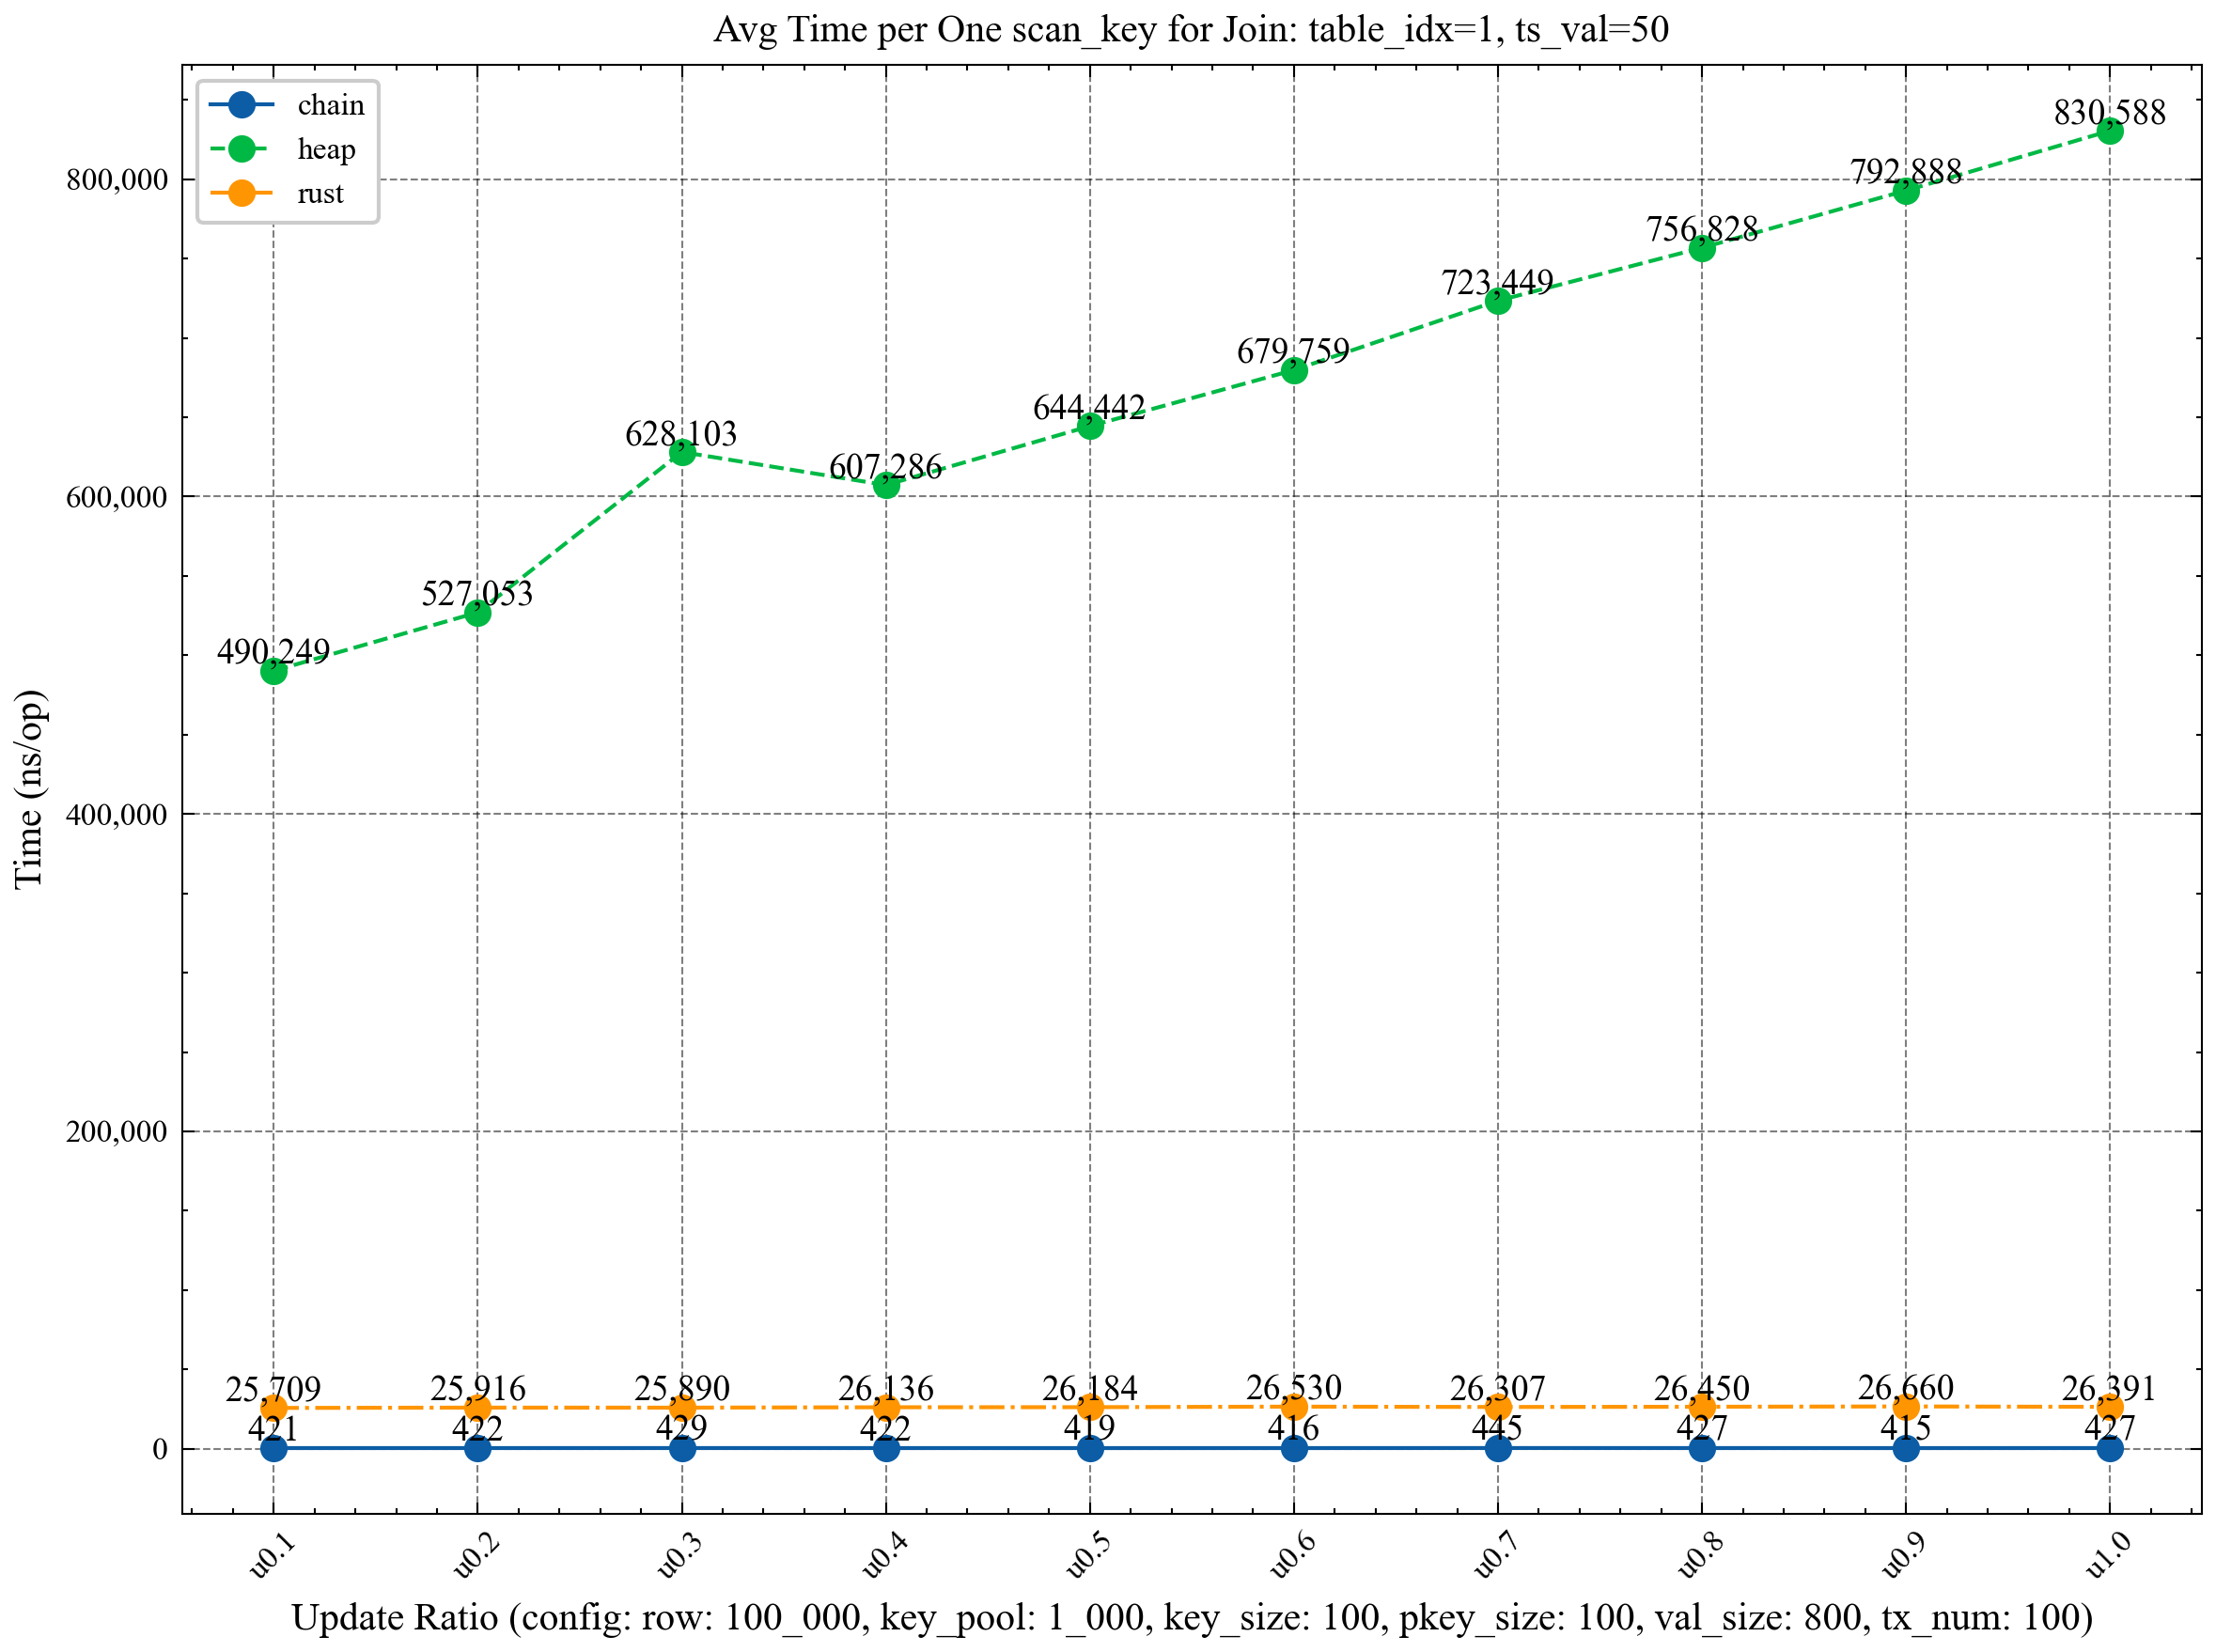

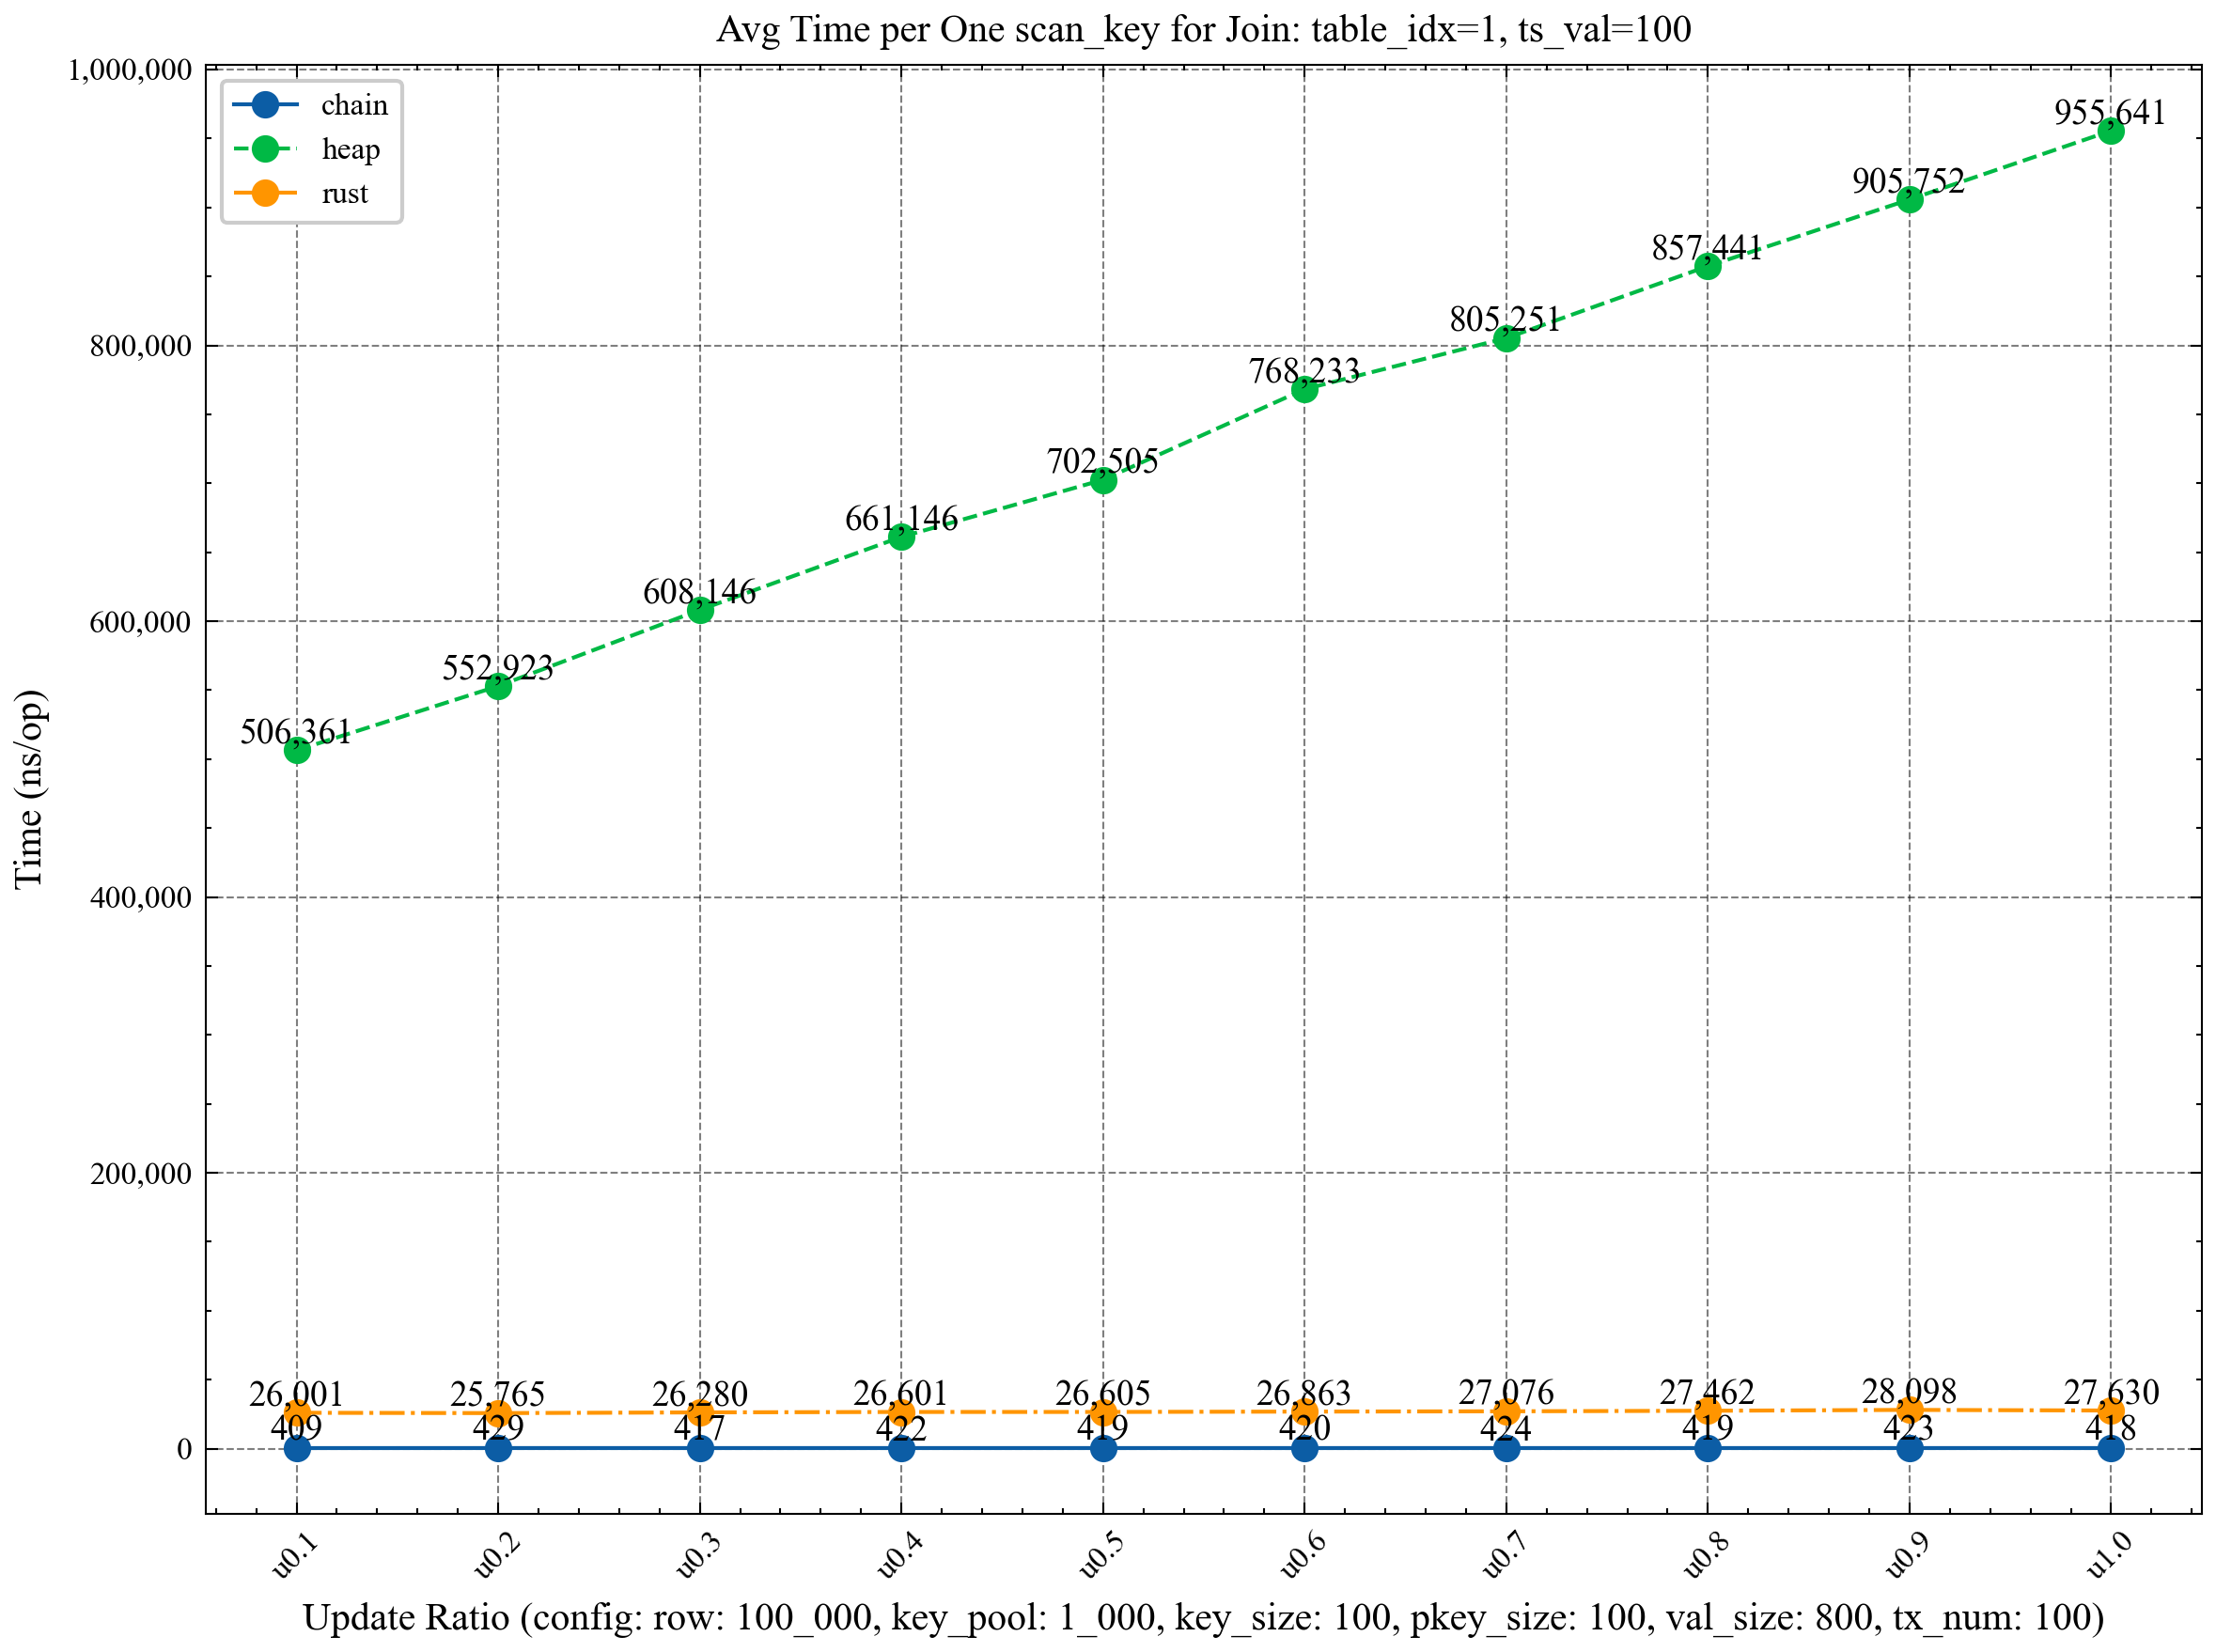

In [41]:
#!/usr/bin/env python3
# In a real Jupyter notebook, you typically wouldn't have the #! line. 
# But you can keep it here if you also run this as a standalone .py script.

import subprocess
import re
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

###############################################################################
# 1) Configuration
###############################################################################

DO_CARGO_BUILD = True      # Build the Rust binary with cargo if True
DEFAULT_BIN_NAME = "join_simulation"
DEFAULT_NUM_ITERATIONS = 10 # how many times to repeat each coverage+hash run
hash_types = ["chain", "heap", "rust"]  # which hash table types to test

# The directory containing "table_0.csv", "txs_...", etc.
csv_dir = os.path.abspath("csv")  

###############################################################################
# 2) Build the Rust binary
###############################################################################
if DO_CARGO_BUILD:
    print("=== Building Rust binary in release mode ===")
    build_cmd = ["cargo", "build", "--release", "--bin", DEFAULT_BIN_NAME]
    result = subprocess.run(build_cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("[ERROR] cargo build failed.\n", result.stderr)
        raise SystemExit(1)
    print("Cargo build completed successfully.\n")

###############################################################################
# 3) Discover coverage logs in the CSV directory
###############################################################################
if not os.path.exists(csv_dir):
    print(f"[ERROR] CSV folder not found: {csv_dir}")
    raise SystemExit(1)

all_files = os.listdir(csv_dir)
coverage_logs = sorted(
    f for f in all_files
    if f.startswith("txs_") and f.endswith("_t0.csv")
)
if not coverage_logs:
    print("No coverage logs found matching pattern txs_*_t0.csv")
    raise SystemExit(0)

coverage_labels = [f[4:-7] for f in coverage_logs]  # e.g. "u0.1" from "txs_u0.1_t0.csv"

print("Discovered coverage logs:")
for lbl, f in zip(coverage_labels, coverage_logs):
    print(f"  coverage label='{lbl}' => file={f}")

###############################################################################
# 4) Path to the Rust binary
###############################################################################
binary_path = os.path.abspath(
    os.path.join("..", "..", "..", "target", "release", DEFAULT_BIN_NAME)
)
if not os.path.exists(binary_path):
    print(f"[ERROR] Binary not found at: {binary_path}")
    raise SystemExit(1)

###############################################################################
# 5) Regex for parsing stdout lines
###############################################################################
insert_re = re.compile(r"Inserted\s+(\d+)\s+rows\s+from\s+\"[^\"]+\"\s+in\s+(\d+)\s+ns")
applied_re = re.compile(r"Applied\s+(\d+)\s+operations\s+from\s+\"([^\"]+)\"\s+in\s+(\d+)\s+ns")
join_pattern = re.compile(r"^txs_join_ts(\d+)_t(\d+)\.csv$")

###############################################################################
# 6) Data structures to hold parse results
###############################################################################
insert_rows   = []  # each row => {coverage_str, hash_type, time_ns_per_row}
coverage_rows = []  # each row => {coverage_str, hash_type, time_ns_per_op}
join_rows     = []  # each row => {coverage_str, hash_type, table_idx, ts_val, time_ns_per_op}

###############################################################################
# 7) Main loop: coverage × hash_types
###############################################################################
num_iterations = DEFAULT_NUM_ITERATIONS

for lbl, ops_file in zip(coverage_labels, coverage_logs):
    for ht in hash_types:
        print(f"\n=== coverage='{lbl}', file={ops_file}, hash_type={ht} ===")

        # We'll gather times across multiple runs:
        insert_times, insert_counts = [], []
        coverage_times, coverage_counts = [], []

        # For join logs, store (time_sum, op_sum) keyed by (table_idx, ts_val)
        join_map = {}

        for iteration in range(num_iterations):
            print(f"   iteration {iteration+1}/{num_iterations}")

            cmd = [
                binary_path,
                "--csv-dir", csv_dir,
                "--table0", "table_0.csv",
                "--txs0", ops_file,
                "-t", ht
            ]
            proc = subprocess.run(cmd, capture_output=True, text=True)
            if proc.returncode != 0:
                print(f"[ERROR] coverage={lbl}, type={ht}, iteration={iteration+1}")
                print(proc.stderr)
                continue

            # Parse stdout line by line
            stdout_lines = proc.stdout.splitlines()
            for line in stdout_lines:
                # 1) Insert line
                m_insert = insert_re.search(line)
                if m_insert:
                    row_count = int(m_insert.group(1))
                    time_ns   = int(m_insert.group(2))
                    insert_times.append(time_ns)
                    insert_counts.append(row_count)
                    continue

                # 2) "Applied" line => coverage or join
                m_applied = applied_re.search(line)
                if m_applied:
                    ops_count = int(m_applied.group(1))
                    fname_str = m_applied.group(2)
                    time_ns   = int(m_applied.group(3))

                    if fname_str == ops_file:
                        # coverage (the main log file)
                        coverage_times.append(time_ns)
                        coverage_counts.append(ops_count)
                    else:
                        # Maybe a join file
                        jmatch = join_pattern.match(fname_str)
                        if jmatch:
                            ts_val = int(jmatch.group(1))
                            tbl_idx = int(jmatch.group(2))
                            key = (tbl_idx, ts_val)
                            if key not in join_map:
                                join_map[key] = [0,0]
                            join_map[key][0] += time_ns
                            join_map[key][1] += ops_count
                    continue
                # else ignore

        # Summarize across runs:
        # A) Insert times
        if insert_times and insert_counts:
            avg_insert_time_ns = sum(insert_times)/len(insert_times)
            avg_insert_count   = sum(insert_counts)/len(insert_counts)
            if avg_insert_count>0:
                insert_time_ns = avg_insert_time_ns / avg_insert_count
            else:
                insert_time_ns = math.nan
        else:
            insert_time_ns = math.nan

        insert_rows.append({
            "coverage_str": lbl,
            "hash_type": ht,
            "time_ns_per_row": insert_time_ns
        })

        # B) Coverage times
        if coverage_times and coverage_counts:
            avg_cov_time_ns = sum(coverage_times)/len(coverage_times)
            avg_cov_count   = sum(coverage_counts)/len(coverage_counts)
            if avg_cov_count>0:
                coverage_time_op = avg_cov_time_ns / avg_cov_count
            else:
                coverage_time_op = math.nan
        else:
            coverage_time_op = math.nan

        coverage_rows.append({
            "coverage_str": lbl,
            "hash_type": ht,
            "time_ns_per_op": coverage_time_op
        })

        # C) Join logs => average times
        for (key, val) in join_map.items():
            (tbl_idx, ts_val) = key
            (time_sum, op_sum) = val
            if op_sum>0:
                join_time_op = time_sum/op_sum
            else:
                join_time_op = math.nan
            join_rows.append({
                "coverage_str": lbl,
                "hash_type": ht,
                "table_idx": tbl_idx,
                "ts_val": ts_val,
                "time_ns_per_op": join_time_op
            })

###############################################################################
# 8) Convert to DataFrames
###############################################################################
insert_df = pd.DataFrame(insert_rows)
coverage_df = pd.DataFrame(coverage_rows)
join_df = pd.DataFrame(join_rows)

print("\n=== Insert DF ===")
print(insert_df)

print("\n=== Coverage DF ===")
print(coverage_df)

print("\n=== Join DF ===")
print(join_df)

if insert_df.empty and coverage_df.empty and join_df.empty:
    print("No valid results. Exiting.")
    raise SystemExit(0)

###############################################################################
# 9) Define label order for coverage, build a mapping for x‑axis positions
###############################################################################
label_order = coverage_labels
label_idx_map = {c: i for i, c in enumerate(label_order)}

###############################################################################
# 10) Plot #1: Insert Time (ns/row) 
###############################################################################
if not insert_df.empty:
    insert_df["x_pos"] = insert_df["coverage_str"].map(label_idx_map)
    x_ticks = np.arange(len(label_order))

    plt.figure(figsize=(8,6))

    # We'll create a nice y-axis formatter with comma grouping
    y_fmt = ticker.StrMethodFormatter('{x:,.0f}')
    plt.gca().yaxis.set_major_formatter(y_fmt)

    for ht in hash_types:
        sub = insert_df[insert_df["hash_type"]==ht].copy()
        sub.sort_values("x_pos", inplace=True)

        # Plot the data
        plt.plot(sub["x_pos"], sub["time_ns_per_row"], marker="o", label=ht)

        # Annotate each data point
        for x, y in zip(sub["x_pos"], sub["time_ns_per_row"]):
            if not math.isnan(y):
                plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

    plt.title("Avg Insert Time for table_0 (ns/row)")
    plt.xlabel("Update Ratio (config: " + config_str + ")")
    plt.ylabel("Time (ns/row)")
    plt.xticks(x_ticks, label_order, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

###############################################################################
# 11) Plot #2: Coverage Time (ns/op)
###############################################################################
if not coverage_df.empty:
    coverage_df["x_pos"] = coverage_df["coverage_str"].map(label_idx_map)
    x_ticks = np.arange(len(label_order))

    plt.figure(figsize=(8,6))

    # y-axis comma grouping
    y_fmt = ticker.StrMethodFormatter('{x:,.0f}')
    plt.gca().yaxis.set_major_formatter(y_fmt)

    for ht in hash_types:
        sub = coverage_df[coverage_df["hash_type"]==ht].copy()
        sub.sort_values("x_pos", inplace=True)

        plt.plot(sub["x_pos"], sub["time_ns_per_op"], marker="o", label=ht)

        for x, y in zip(sub["x_pos"], sub["time_ns_per_op"]):
            if not math.isnan(y):
                plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

    plt.title("Avg Update Time per One Update Operation (ns/op)")
    plt.xlabel("Update Ratio (config: " + config_str + ")")
    plt.ylabel("Time (ns/op)")
    plt.xticks(x_ticks, label_order, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

###############################################################################
# 12) Plot #3: Join logs => for each (table_idx, ts_val)
###############################################################################
if not join_df.empty:
    pairs = join_df[["table_idx","ts_val"]].drop_duplicates()
    pairs = pairs.sort_values(by=["table_idx","ts_val"]).values.tolist()

    for (tid, tsval) in pairs:
        sub = join_df[(join_df["table_idx"]==tid) & (join_df["ts_val"]==tsval)].copy()
        sub["x_pos"] = sub["coverage_str"].map(label_idx_map)
        sub.sort_values("x_pos", inplace=True)

        plt.figure(figsize=(8,6))
        y_fmt = ticker.StrMethodFormatter('{x:,.0f}')
        plt.gca().yaxis.set_major_formatter(y_fmt)

        for ht in hash_types:
            sub_ht = sub[sub["hash_type"]==ht]
            plt.plot(sub_ht["x_pos"], sub_ht["time_ns_per_op"], marker="o", label=ht)

            for x, y in zip(sub_ht["x_pos"], sub_ht["time_ns_per_op"]):
                if not math.isnan(y):
                    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

        plt.title(f"Avg Time per One scan_key for Join: table_idx={tid}, ts_val={tsval}")
        plt.xlabel("Update Ratio (config: " + config_str + ")")
        plt.ylabel("Time (ns/op)")
        x_ticks = np.arange(len(label_order))
        plt.xticks(x_ticks, label_order, rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.show()
